# PPMI Dataset Exploration

Initial exploration of the PPMI Parkinson's disease dataset.

**Dataset**: PPMI Curated Data Cut (March 21, 2025)
- 15,316 patient visits
- 181 features
- Longitudinal data (up to 13 years)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load Data

In [2]:
# Define data paths
data_dir = Path('../../PPMI_Curated_Data_Cut_Public_20250321')
data_file = data_dir / '20250310-Table 1.csv'
dict_file = data_dir / 'Data dictionary-Table 1.csv'
info_file = data_dir / 'Information-Table 1.csv'

# Load main dataset
df = pd.read_csv(data_file)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (15316, 181)
Memory usage: 26.77 MB


/var/folders/yl/dtwf9y213rj7031w6m3fq_xh0000gn/T/ipykernel_25810/2886381452.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)


In [3]:
# Load data dictionary
data_dict = pd.read_csv(dict_file)
print(f"Data dictionary shape: {data_dict.shape}")
data_dict.head()

Data dictionary shape: (409, 10)


,Category,Variable,Description,Code,Decode,Derived Variable,Original Variable(s),Original Dataset(s),Derivation Notes,Unnamed: 9
0,ID,SITE,Blinded Site ID,-,-,Yes,CNO,Multiple,Derived from CNO,NaN
1,ID,PATNO,Participant ID,-,-,No,PATNO,Multiple,NaN,NaN
2,ID,COHORT,Cohort at Enrollment,1,PD Participant,No,COHORT,STATUS,NaN,NaN
3,NaN,NaN,NaN,2,Healthy Control,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,3,SWEDD,NaN,NaN,NaN,NaN,NaN


## 2. Basic Data Overview

In [4]:
# Display first few rows
df.head()

,SITE,PATNO,COHORT,subgroup,enroll_phase,enroll_source,prod_subset,HIQ_RBD,study_status,NSD_Status,NSD_STAGE,PRIMDIAG,OTHNEURO,EVENT_ID,YEAR,visit_date,age,age_at_visit,SEX,EDUCYRS,race,HISPLAT,ASHKJEW,AFICBERB,BASQUE,fampd,fampd_bin,handed,howlive,sex_orient,BMI,agediag,ageonset,duration,duration_yrs,DOMSIDE,sym_tremor,sym_rigid,sym_brady,sym_posins,sym_other,sym_unknown,PDTRTMNT,LEDD,age_datscan,age_LP,age_upsit,upsit,upsit_pctl,upsit_pctl15,moca,bjlot,DVS_JLO_MSSA,DVS_JLO_MSSAE,clockdraw,DVT_CLCKDRAW,DVZ_CLCKDRAW,hvlt_discrimination,hvlt_immediaterecall,hvlt_retention,HVLTFPRL,HVLTRDLY,HVLTREC,DVT_TOTAL_RECALL,DVT_DELAYED_RECALL,DVT_RETENTION,DVT_RECOG_DISC_INDEX,lexical,DVT_FAS,DVS_FAS,lns,DVS_LNS,MODBNT,DVS_BNT,PCTL_BNT,SDMTOTAL,DVT_SDM,DVSD_SDM,TMT_A,TMT_B,DVZ_TMTA,DVZ_TMTB,VLTANIM,DVT_SFTANIM,DVS_SFTANIM,MCI_testscores,cogstate,MSEADLG,quip,quip_any,quip_gamble,quip_sex,quip_buy,quip_eat,quip_hobby,quip_pund,quip_walk,ess,rem,gds,stai,stai_state,stai_trait,scopa,scopa_gi,scopa_ur,scopa_cv,scopa_therm,scopa_pm,scopa_sex,orthostasis,hy,hy_on,NHY,NHY_ON,pigd,pigd_on,td_pigd,td_pigd_on,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1FATG,updrs1_score,updrs2_score,updrs3_score,updrs3_score_on,updrs4_score,updrs_totscore,updrs_totscore_on,pm_any,pm_adl_any,pm_fd_any,pm_auto_any,pm_cog_any,pm_mc_any,pm_wb_any,CSFSAA,CSFSAA_assay,abeta,abeta_LLOD,abeta_ULOD,tau,tau_LLOD,ptau,ptau_LLOD,asyn,hemohi,urate,ptau217_plasma,bd_tau_plasma,total_di_18_1_BMP,total_di_22_6_BMP,_2_2__di_22_6_BMP,NFL_CSF,nfl_serum,APOE,APOE_e4,lowput_expected,DATSCAN_CAUDATE_L,DATSCAN_CAUDATE_R,con_caudate,ips_caudate,mean_caudate,DATSCAN_PUTAMEN_L,DATSCAN_PUTAMEN_R,con_putamen,ips_putamen,mean_putamen,con_striatum,ips_striatum,mean_striatum,Stage_partial_UPDRS1,Stage_subpark,Stage_PDTreat,Stage_S,Stage_D,Stage_G
0,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,1.0,3,1.0,NaN,BL,0,10/2020,67.386301,67.386301,1,16.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,NaN,NaN,24.615211,66.326027,62.323288,12.733333,1.060274,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,67.306849,67.386301,67.386301,27.0,17.5,0.0,26.0,13.0,13.0,12.16,5.0,47.99,-0.20,1.0,19.0,1.000000,1.0,8.0,2.0,33.0,42.0,57.0,20.0,32.0,41.0,8.0,11.0,12.0,58.0,10.0,41 to 59,50.0,55.83,0.583,43.0,87.0,-1.37,-2.14,19.0,49.0,10.0,1.0,1.0,90.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,5.0,0.0,48.0,27.0,21.0,11.0,5.0,3.0,1.0,1.0,0.0,1.0,0.0,2.0,2.0,2.0,2.0,0.4,0.4,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,7.0,10.0,24.0,24.0,NaN,41.0,41.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e3/e4,1.0,0.422884,2.15,1.53,1.53,2.15,1.840,1.37,0.79,0.79,1.37,1.080,2.32,3.52,1.4600,7.0,22.0,0.0,1.0,1.0,NaN
1,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,1.0,3,1.0,NaN,V04,1,11/2021,67.386301,68.512329,1,16.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,NaN,NaN,24.898144,66.326027,62.323288,12.733333,1.060274,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,68.536986,68.536986,NaN,NaN,NaN,NaN,26.0,13.0,13.0,12.16,7.0,72.62,2.26,9.0,14.0,0.714286,2.0,5.0,11.0,31.0,36.0,42.0,42.0,38.0,48.0,10.0,8.0,9.0,56.0,9.0,29 to 40,50.0,55.83,0.583,40.0,59.0,-0.92,0.87,22.0,53.0,11.0,0.0,1.0,95.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.0,58.0,32.0,26.0,16.0,7.0,4.0,0.0,2.0,1.0,2.0,0.0,2.0,2.0,2.0,2.0,0.4,0.4,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,8.0,33.0,33.0,NaN,47.0,47.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,e3/e4,1.0,0.486240,2.00,1.39,1.39,2.00,1.695,1.18,0.90,0.90,1.18,1.040,2.29,3.18,1.3675,5.0,29.0,0.0,1.0,1.0,NaN
2,19,100001,1,Sporadic PD,2,NaN,NaN,NaN,Active,1.0,3,1.0,NaN,V06,2,11/2022,67.386301,69.528767,1,16.0,1.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,NaN,NaN,23.596650,66.326027,62.323288,12.733333,1.060274,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,69.531507,69.531507,NaN,NaN,NaN,NaN,25.0,12.0,12.0,11.06,7.0,72.62,2.26,11.0,15.0,0.750000,0.0,6.0,11.0,33.0,40.0,44.0,50.0,29.0,41.0,8.0,8.0,9.0,57.0,10.0,41 to 59,44.0,50.00,0.000,43.0,73.0,-1.37,-0.63,23.0,57.0,12.0,0.0,

In [5]:
# Data types
print("Data types:")
print(df.dtypes.value_counts())
print("\nColumn data types:")
df.dtypes

Data types:
float64    165
object      10
int64        6
Name: count, dtype: int64

Column data types:


SITE               int64
PATNO              int64
COHORT             int64
subgroup          object
enroll_phase       int64
                  ...   
Stage_subpark    float64
Stage_PDTreat    float64
Stage_S          float64
Stage_D          float64
Stage_G          float64
Length: 181, dtype: object

In [6]:
# Basic statistics
df.describe()

,SITE,PATNO,COHORT,enroll_phase,HIQ_RBD,NSD_Status,PRIMDIAG,YEAR,age,age_at_visit,SEX,EDUCYRS,race,HISPLAT,ASHKJEW,AFICBERB,BASQUE,fampd,fampd_bin,handed,howlive,sex_orient,BMI,agediag,ageonset,duration,duration_yrs,DOMSIDE,sym_tremor,sym_rigid,sym_brady,sym_posins,sym_other,sym_unknown,PDTRTMNT,LEDD,age_datscan,age_LP,age_upsit,upsit,upsit_pctl,upsit_pctl15,moca,bjlot,DVS_JLO_MSSA,DVS_JLO_MSSAE,clockdraw,DVT_CLCKDRAW,DVZ_CLCKDRAW,hvlt_discrimination,hvlt_immediaterecall,hvlt_retention,HVLTFPRL,HVLTRDLY,HVLTREC,DVT_TOTAL_RECALL,DVT_DELAYED_RECALL,DVT_RETENTION,DVT_RECOG_DISC_INDEX,lexical,DVT_FAS,DVS_FAS,lns,DVS_LNS,MODBNT,DVS_BNT,SDMTOTAL,DVT_SDM,DVSD_SDM,TMT_A,TMT_B,DVZ_TMTA,DVZ_TMTB,VLTANIM,DVT_SFTANIM,DVS_SFTANIM,MCI_testscores,cogstate,MSEADLG,quip,quip_any,quip_gamble,quip_sex,quip_buy,quip_eat,quip_hobby,quip_pund,quip_walk,ess,rem,gds,stai,stai_state,stai_trait,scopa,scopa_gi,scopa_ur,scopa_cv,scopa_therm,scopa_pm,scopa_sex,orthostasis,hy,hy_on,NHY,NHY_ON,pigd,pigd_on,td_pigd,td_pigd_on,NP1COG,NP1HALL,NP1DPRS,NP1ANXS,NP1APAT,NP1DDS,NP1FATG,updrs1_score,updrs2_score,updrs3_score,updrs3_score_on,updrs4_score,updrs_totscore,updrs_totscore_on,pm_any,pm_adl_any,pm_fd_any,pm_auto_any,pm_cog_any,pm_mc_any,pm_wb_any,CSFSAA,CSFSAA_assay,abeta,abeta_LLOD,abeta_ULOD,tau,tau_LLOD,ptau,ptau_LLOD,asyn,hemohi,urate,ptau217_plasma,bd_tau_plasma,total_di_18_1_BMP,total_di_22_6_BMP,_2_2__di_22_6_BMP,NFL_CSF,nfl_serum,APOE_e4,lowput_expected,DATSCAN_CAUDATE_L,DATSCAN_CAUDATE_R,con_caudate,ips_caudate,mean_caudate,DATSCAN_PUTAMEN_L,DATSCAN_PUTAMEN_R,con_putamen,ips_putamen,mean_putamen,con_striatum,ips_striatum,mean_striatum,Stage_partial_UPDRS1,Stage_subpark,Stage_PDTreat,Stage_S,Stage_D,Stage_G
count,15316.000000,15316.000000,15316.000000,15316.000000,1814.000000,6696.000000,15223.000000,15316.000000,15316.000000,15316.000000,15316.000000,15281.000000,15230.000000,15218.000000,12772.000000,12857.000000,12813.000000,15277.000000,15277.000000,15275.000000,2654.000000,2650.000000,14233.000000,7227.000000,7122.000000,7227.000000,7227.000000,7203.000000,7166.000000,6973.000000,7057.000000,7017.000000,7096.000000,7220.000000,15165.000000,15316.000000,7393.000000,11320.000000,5583.000000,5563.000000,5563.000000,5576.000000,14665.000000,14568.000000,14568.000000,14533.000000,8032.000000,8032.000000,8032.000000,14577.000000,14618.000000,14591.000000,14577.000000,14592.000000,14577.000000,14617.000000,14592.000000,14591.000000,14575.000000,8106.000000,8071.000000,8106.000000,14593.000000,14593.000000,7862.000000,7615.000000,14584.000000,14549.000000,14549.000000,8084.000000,8075.000000,8052.000000,8043.000000,14636.000000,14601.000000,14636.000000,14527.000000,13833.000000,14060.000000,15178.000000,15178.000000,15170.000000,15160.000000,15169.000000,15174.000000,15174.000000,15174.000000,15171.000000,15187.000000,15169.000000,15158.000000,15146.000000,15156.000000,15149.000000,15110.000000,15169.000000,15173.000000,15175.000000,15172.000000,15184.000000,15153.000000,14571.000000,13502.000000,14821.000000,13502.000000,14821.00000,13109.000000,14333.000000,13094.000000,14315.000000,15256.000000,15257.000000,15255.000000,15256.000000,15255.000000,15229.000000,15229.000000,15160.000000,15214.000000,13043.000000,14274.000000,5373.000000,12947.000000,14165.000000,15311.000000,15302.000000,14060.000000,15285.000000,15302.000000,15037.000000,15301.000000,1841.000000,1841.000000,4170.000000,4689.000000,4689.000000,4594.000000,4712.000000,4355.000000,4713.000000,2362.000000,2364.000000,7358.000000,194.000000,193.000000,1712.000000,1712.000000,1712.000000,1344.000000,4004.000000,14824.000000,3724.000000,3724.000000,3724.000000,3705.000000,3705.000000,3724.000000,3724.000000,3724.000000,3705.000000,3705.000000,3724.000000,3705.000000,3705.000000,3724.000000,7154.000000,5617.000000,7211.000000,6683.000000,6968.000000,937.000000
mean,36.572081,80727.240598,2.355837,1.321429,0.518743,0.853943,11.623267,3.053343,62.991596,66.080242,0.566205,16.046594,1.115299,0.

## 3. Cohort Distribution

In [7]:
# Check cohort distribution
print("Cohort distribution:")
print(df['COHORT'].value_counts())
print(f"\nTotal visits: {len(df)}")
print(f"Unique patients: {df['PATNO'].nunique()}")

Cohort distribution:
COHORT
1    7021
4    6136
2    1960
3     199
Name: count, dtype: int64

Total visits: 15316
Unique patients: 4035


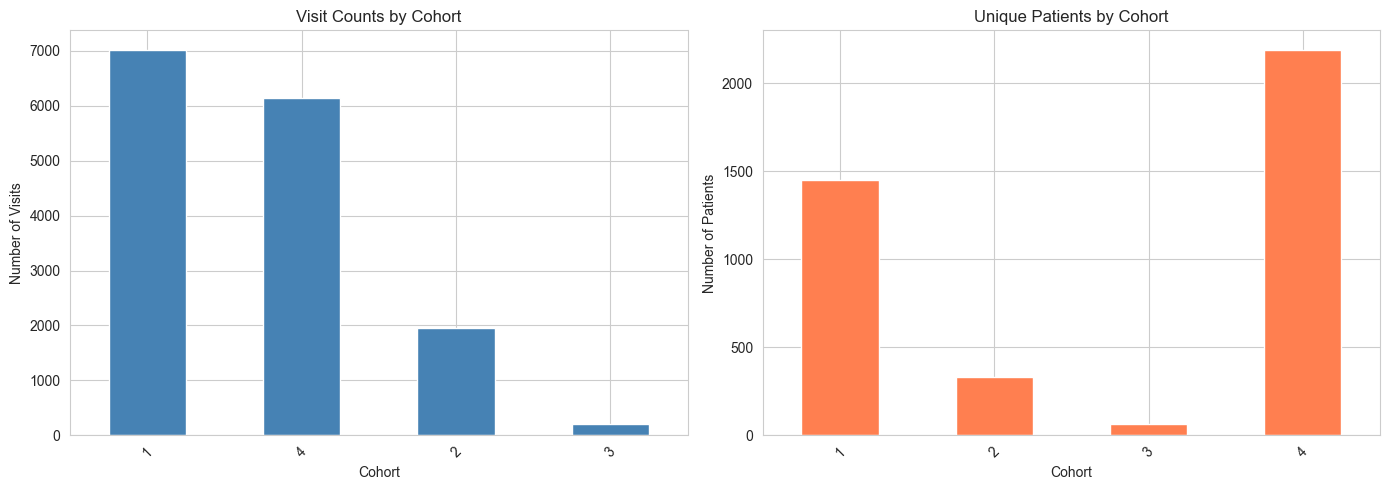

In [8]:
# Visualize cohort distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by cohort
df['COHORT'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Visit Counts by Cohort')
axes[0].set_xlabel('Cohort')
axes[0].set_ylabel('Number of Visits')
axes[0].tick_params(axis='x', rotation=45)

# Unique patients by cohort
df.groupby('COHORT')['PATNO'].nunique().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Unique Patients by Cohort')
axes[1].set_xlabel('Cohort')
axes[1].set_ylabel('Number of Patients')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Visit Distribution

In [9]:
# Visit event distribution
print("Visit event distribution:")
print(df['EVENT_ID'].value_counts().sort_index())

Visit event distribution:
EVENT_ID
BL     4035
PW        5
ST       13
V04    2894
V06    1816
V08    1270
V10    1056
V12     993
V13     722
V14     700
V15     489
V16     330
V17     350
V18     281
V19     223
V20     121
V21      18
Name: count, dtype: int64


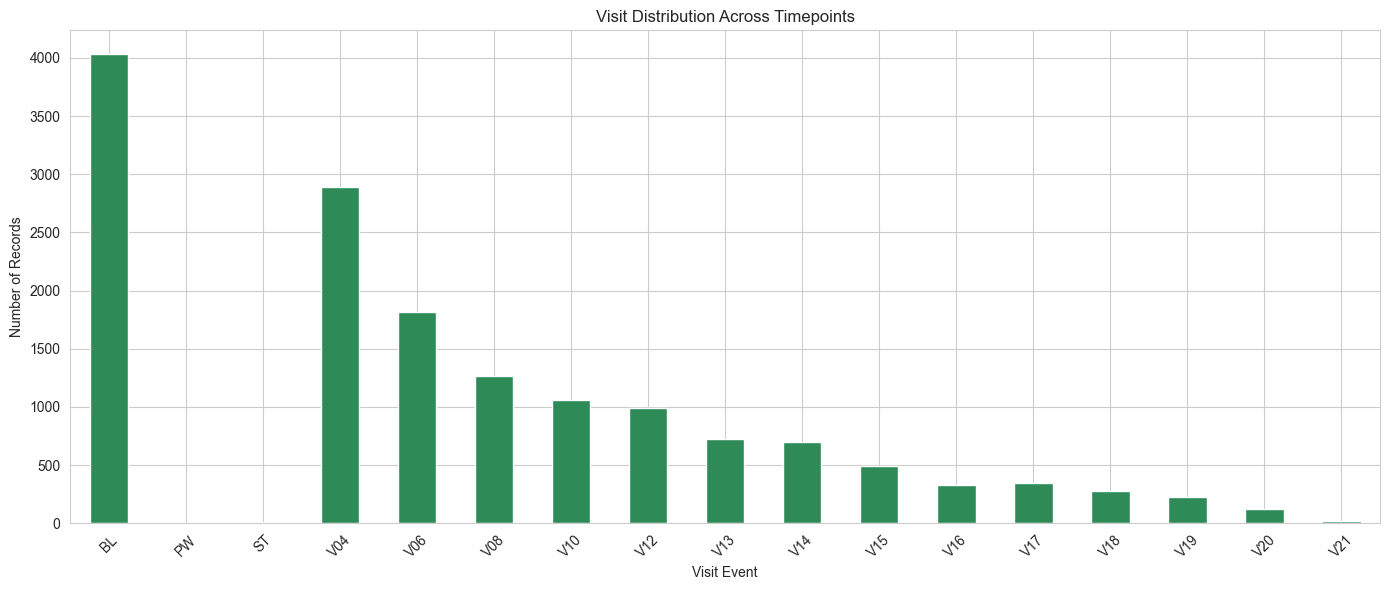

In [10]:
# Visualize visits over time
fig, ax = plt.subplots(figsize=(14, 6))
visit_counts = df['EVENT_ID'].value_counts().sort_index()
visit_counts.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Visit Distribution Across Timepoints')
ax.set_xlabel('Visit Event')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Missing Data Analysis

In [11]:
# Calculate missing percentages
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 20 features with most missing data:")
print(missing_pct.head(20))

Top 20 features with most missing data:
bd_tau_plasma        98.739880
ptau217_plasma       98.733351
OTHNEURO             98.184905
Stage_G              93.882215
NFL_CSF              91.224863
total_di_18_1_BMP    88.822147
total_di_22_6_BMP    88.822147
_2_2__di_22_6_BMP    88.822147
HIQ_RBD              88.156177
CSFSAA_assay         87.979890
CSFSAA               87.979890
asyn                 84.578219
hemohi               84.565161
sex_orient           82.697832
howlive              82.671716
prod_subset          81.496474
enroll_source        78.009924
ips_caudate          75.809611
con_striatum         75.809611
ips_putamen          75.809611
dtype: float64


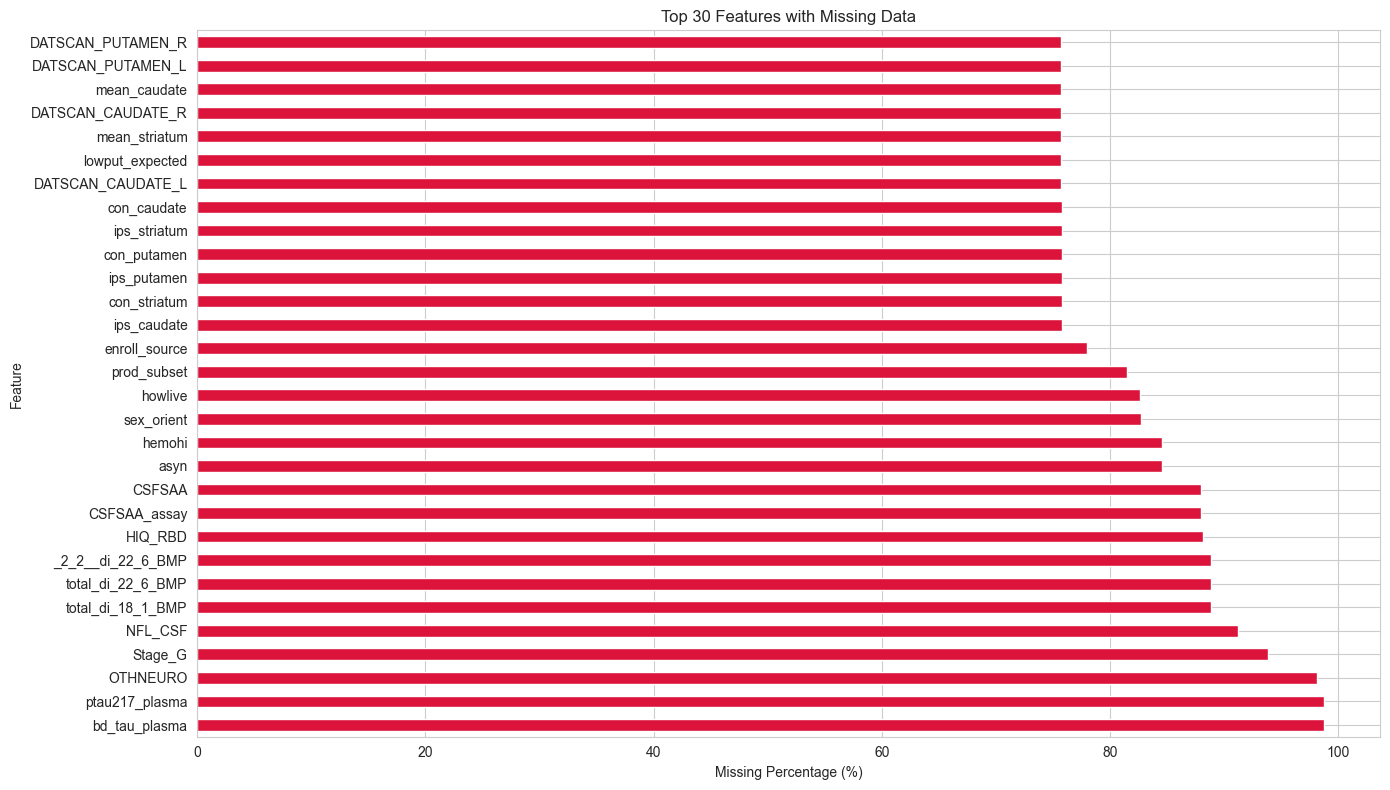

In [12]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(14, 8))
top_missing = missing_pct[missing_pct > 0].head(30)
top_missing.plot(kind='barh', ax=ax, color='crimson')
ax.set_title('Top 30 Features with Missing Data')
ax.set_xlabel('Missing Percentage (%)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Feature Categories

Explore different categories of features in the dataset.

In [13]:
# List all column names
print("All features:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

All features:
  1. SITE
  2. PATNO
  3. COHORT
  4. subgroup
  5. enroll_phase
  6. enroll_source
  7. prod_subset
  8. HIQ_RBD
  9. study_status
 10. NSD_Status
 11. NSD_STAGE
 12. PRIMDIAG
 13. OTHNEURO
 14. EVENT_ID
 15. YEAR
 16. visit_date
 17. age
 18. age_at_visit
 19. SEX
 20. EDUCYRS
 21. race
 22. HISPLAT
 23. ASHKJEW
 24. AFICBERB
 25. BASQUE
 26. fampd
 27. fampd_bin
 28. handed
 29. howlive
 30. sex_orient
 31. BMI
 32. agediag
 33. ageonset
 34. duration
 35. duration_yrs
 36. DOMSIDE
 37. sym_tremor
 38. sym_rigid
 39. sym_brady
 40. sym_posins
 41. sym_other
 42. sym_unknown
 43. PDTRTMNT
 44. LEDD
 45. age_datscan
 46. age_LP
 47. age_upsit
 48. upsit
 49. upsit_pctl
 50. upsit_pctl15
 51. moca
 52. bjlot
 53. DVS_JLO_MSSA
 54. DVS_JLO_MSSAE
 55. clockdraw
 56. DVT_CLCKDRAW
 57. DVZ_CLCKDRAW
 58. hvlt_discrimination
 59. hvlt_immediaterecall
 60. hvlt_retention
 61. HVLTFPRL
 62. HVLTRDLY
 63. HVLTREC
 64. DVT_TOTAL_RECALL
 65. DVT_DELAYED_RECALL
 66. DVT_RETENTION
 67

In [14]:
# Identify feature categories (based on naming patterns)
biomarker_cols = [col for col in df.columns if any(marker in col.lower() for marker in 
                  ['tau', 'abeta', 'synuclein', 'urate', 'neurofilament', 'plasma', 'csf', 'serum'])]
imaging_cols = [col for col in df.columns if any(img in col.lower() for img in 
                ['caudate', 'putamen', 'striatum', 'datscan'])]
updrs_cols = [col for col in df.columns if 'updrs' in col.lower()]
cognitive_cols = [col for col in df.columns if any(cog in col.lower() for cog in 
                  ['moca', 'hvlt', 'naming', 'clock', 'trail', 'letter', 'symbol', 'benton'])]
genetic_cols = [col for col in df.columns if 'apoe' in col.lower()]

print(f"Biomarker features: {len(biomarker_cols)}")
print(f"Imaging features: {len(imaging_cols)}")
print(f"UPDRS features: {len(updrs_cols)}")
print(f"Cognitive features: {len(cognitive_cols)}")
print(f"Genetic features: {len(genetic_cols)}")

Biomarker features: 14
Imaging features: 14
UPDRS features: 8
Cognitive features: 8
Genetic features: 2


## 7. Demographics

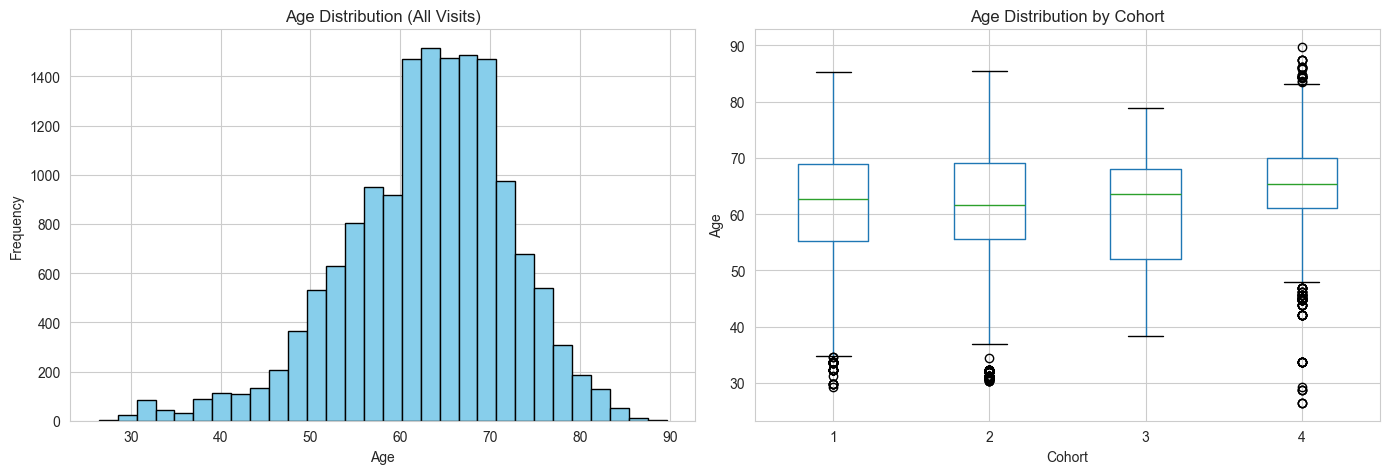

In [15]:
# Age distribution
if 'age' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    df['age'].hist(bins=30, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('Age Distribution (All Visits)')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    
    df.boxplot(column='age', by='COHORT', ax=axes[1])
    axes[1].set_title('Age Distribution by Cohort')
    axes[1].set_xlabel('Cohort')
    axes[1].set_ylabel('Age')
    plt.suptitle('')
    
    plt.tight_layout()
    plt.show()

In [16]:
# Sex distribution
if 'sex' in df.columns:
    print("Sex distribution:")
    print(df['sex'].value_counts())
    print("\nSex by cohort:")
    print(pd.crosstab(df['COHORT'], df['sex'], normalize='index') * 100)

## 8. Key Clinical Variables

In [17]:
# UPDRS scores
if updrs_cols:
    print("UPDRS scores summary:")
    print(df[updrs_cols].describe())

UPDRS scores summary:
       updrs1_score  updrs2_score  updrs3_score  updrs3_score_on  \
count  15160.000000  15214.000000  13043.000000     14274.000000   
mean       6.994921      5.399369     14.228092        12.859185   
std        5.546787      6.528114     15.522072        13.169550   
min        0.000000      0.000000      0.000000         0.000000   
25%        3.000000      0.000000      2.000000         2.000000   
50%        6.000000      3.000000      8.000000         8.000000   
75%       10.000000      8.000000     24.000000        21.000000   
max       38.000000     48.000000    100.000000        89.000000   

       updrs4_score  updrs_totscore  updrs_totscore_on  Stage_partial_UPDRS1  
count   5373.000000    12947.000000       14165.000000           7154.000000  
mean       2.506979       25.544450          24.915284              8.049623  
std        3.340087       23.248211          21.291919              5.451531  
min        0.000000        0.000000           0.0

In [18]:
# MoCA scores (cognitive)
if 'moca_total' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    df.boxplot(column='moca_total', by='COHORT', ax=ax)
    ax.set_title('MoCA Total Score by Cohort')
    ax.set_xlabel('Cohort')
    ax.set_ylabel('MoCA Score')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()

## 9. New Features (March 2025)

Explore newly added NSD-ISS staging and plasma biomarkers.

In [19]:
# NSD-ISS staging variables
nsd_cols = [col for col in df.columns if 'nsd' in col.lower()]
print(f"NSD-ISS features: {len(nsd_cols)}")
print(nsd_cols)

if nsd_cols:
    print("\nNSD-ISS summary:")
    print(df[nsd_cols].describe())

NSD-ISS features: 2
['NSD_Status', 'NSD_STAGE']

NSD-ISS summary:
        NSD_Status
count  6696.000000
mean      0.853943
std       0.353190
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       1.000000


In [20]:
# Plasma biomarkers
plasma_cols = [col for col in df.columns if 'plasma' in col.lower()]
print(f"Plasma biomarker features: {len(plasma_cols)}")
print(plasma_cols)

if plasma_cols:
    print("\nPlasma biomarker summary:")
    print(df[plasma_cols].describe())

Plasma biomarker features: 2
['ptau217_plasma', 'bd_tau_plasma']

Plasma biomarker summary:
       ptau217_plasma  bd_tau_plasma
count      194.000000     193.000000
mean         0.037260       4.984971
std          0.023896       1.654810
min          0.006700       2.015600
25%          0.023400       3.889300
50%          0.030700       4.723800
75%          0.044375       5.796800
max          0.188900      12.617800


## 10. Next Steps

Based on this initial exploration:
1. Investigate newly added NSD-ISS staging variables
2. Analyze plasma biomarkers (ptau217, bd_tau)
3. Examine temporal progression patterns
4. Feature selection and importance analysis
5. Build predictive models
6. Compare with previous findings